In [ ]:
!nvidia-smi
!pip install wandb
!pip install grad-cam
!pip install -q lime scikit-image


In [ ]:

# === Core Python Utilities ===
import os, time
import numpy as np
# Ensure numpy is available and check version compatibility
try:
    assert np is not None, "NumPy is not available"
    np_version = np.__version__
    print(f"✓ NumPy version: {np_version}")
    
    # Check for NumPy 2.x compatibility issues with torchvision
    if np_version.startswith('2.'):
        print("⚠ Warning: NumPy 2.x detected. Some PyTorch/torchvision versions may have compatibility issues.")
        print("  If you encounter 'Numpy is not available' errors, try: pip install 'numpy<2'")
        print("  Or upgrade torchvision: pip install --upgrade torchvision")
except (ImportError, AssertionError) as e:
    print(f" NumPy import error: {e}")
    print("Please install numpy: pip install numpy")
    raise
import pandas as pd
from PIL import Image
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import warnings
from tempfile import TemporaryDirectory

# === PyTorch Core ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# === Weights & Biases (WMDB/Weave) ===
import wandb # Added import statement
wandb.login()  # will give you a link in Colab the first time

# === TorchVision (for pretrained models + transforms) ===
import torchvision
from torchvision.transforms import functional as TF
from torchvision import models, transforms, datasets
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

# === Evaluation + Splitting ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# === Explainability (Grad-CAM) ===
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# === Explainability (Lime) ===
from lime import lime_image
from skimage.segmentation import mark_boundaries

import seaborn as sns
from sklearn.metrics import confusion_matrix


# === Environment Setup ===
warnings.filterwarnings("ignore")

# Use Apple MPS (Metal), CUDA if available, else CPU
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print("CUDA available:", torch.cuda.is_available())



/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


KeyboardInterrupt: 

In [9]:
from google.colab import drive
drive.mount('/content/drive')

# Define the source and destination paths
DR_DATA_SOURCE = "/content/drive/MyDrive/RetinXplain/dr-data"
DR_DATA_LOCAL = "/content/dr-data-local"

# Check if the local directory exists, if not, copy the data
if not os.path.exists(DR_DATA_LOCAL):
    print(f"Copying data from {DR_DATA_SOURCE} to {DR_DATA_LOCAL}...")
    !cp -r "{DR_DATA_SOURCE}" "{DR_DATA_LOCAL}"
    print("Data copy complete.")
else:
    print(f"Local data directory {DR_DATA_LOCAL} already exists. Skipping copy.")


DATA_ROOT = DR_DATA_LOCAL
DATA_DIR  = os.path.join(DATA_ROOT, "aptos")
print("APTOS folder:", DATA_DIR)
print("Contents:", os.listdir(DATA_DIR))


APTOS_ROOT = os.path.join(DATA_ROOT, "aptos")

train_csv_path = os.path.join(APTOS_ROOT, "train.csv")
val_csv_path   = os.path.join(APTOS_ROOT, "valid.csv")   # or "val.csv" if that's what you named it
test_csv_path  = os.path.join(APTOS_ROOT, "test.csv")    # only if you actually have this

train_df = pd.read_csv(train_csv_path)
val_df   = pd.read_csv(val_csv_path)
test_df  = pd.read_csv(test_csv_path)    # comment out if no test split yet

train_images = os.path.join(APTOS_ROOT, "train_images")
valid_images = os.path.join(APTOS_ROOT, "val_images")
test_images  = os.path.join(APTOS_ROOT, "test_images")

# Helper function to filter DataFrames by image existence
def _filter_dataframe_by_image_existence(df, image_dir):
    existing_images = []
    for img_id in df['id_code']:
        png_path = os.path.join(image_dir, f"{img_id}.png")
        jpg_path = os.path.join(image_dir, f"{img_id}.jpg")
        if os.path.exists(png_path) or os.path.exists(jpg_path):
            existing_images.append(img_id)
    return df[df['id_code'].isin(existing_images)]

# Filter DataFrames to ensure all listed images exist
train_df = _filter_dataframe_by_image_existence(train_df, train_images)
val_df = _filter_dataframe_by_image_existence(val_df, valid_images)
test_df = _filter_dataframe_by_image_existence(test_df, test_images)

print("Train CSV:", train_csv_path)
print("Train images folder:", train_images)
print(train_df.head())

Mounted at /content/drive
Copying data from /content/drive/MyDrive/RetinXplain/dr-data to /content/dr-data-local...
Data copy complete.
APTOS folder: /content/dr-data-local/aptos
Contents: ['train_images', 'test_images', 'train.csv', 'test.csv', 'valid.csv', 'val_images']
Train CSV: /content/dr-data-local/aptos/train.csv
Train images folder: /content/dr-data-local/aptos/train_images
        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0


In [18]:

class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}
# 1. Count images in your train_images folder
train_files = [f for f in os.listdir(train_images) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
print("Images in folder:", len(train_files))

# 2. Count rows in your CSV
raw_train_df = pd.read_csv(train_csv_path)
print("Rows in train.csv:", raw_train_df.shape[0])

# 3. See how many labels in CSV do not match an actual file
csv_ids = set(raw_train_df["id_code"].astype(str))
folder_ids = set([os.path.splitext(f)[0] for f in train_files])

extra_images = folder_ids - csv_ids
missing_images = csv_ids - folder_ids

# === Split summaries ===

print("\n======================")
print(" Dataset Size Summary")
print("======================")
print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

print("\n============================")
print(" Class Distribution — Train ")
print("============================")
train_counts = train_df["diagnosis"].value_counts().sort_index()
for k, v in train_counts.items():
    print(f"{k} ({class_names[k]}): {v}")

print("\n==============================")
print(" Class Distribution — Validation")
print("==============================")
val_counts = val_df["diagnosis"].value_counts().sort_index()
for k, v in val_counts.items():
    print(f"{k} ({class_names[k]}): {v}")

print("\n==========================")
print(" Class Distribution — Test")
print("==========================")
test_counts = test_df["diagnosis"].value_counts().sort_index()
for k, v in test_counts.items():
    print(f"{k} ({class_names[k]}): {v}")

print("\n=====================================")
print(" Image Existence / CSV Consistency Check")
print("=====================================")
print(f"Images in folder: {len(train_files)}")
print(f"Rows in train.csv: {raw_train_df.shape[0]}")
print(f"Images in folder but NOT in CSV: {len(extra_images)}")
print(f"Images in CSV but NOT in folder: {len(missing_images)}")


Images in folder: 2930
Rows in train.csv: 2930

 Dataset Size Summary
Train set size: 2930
Validation set size: 366
Test set size: 366

 Class Distribution — Train 
0 (No DR): 1434
1 (Mild): 300
2 (Moderate): 808
3 (Severe): 154
4 (Proliferative DR): 234

 Class Distribution — Validation
0 (No DR): 172
1 (Mild): 40
2 (Moderate): 104
3 (Severe): 22
4 (Proliferative DR): 28

 Class Distribution — Test
0 (No DR): 199
1 (Mild): 30
2 (Moderate): 87
3 (Severe): 17
4 (Proliferative DR): 33

 Image Existence / CSV Consistency Check
Images in folder: 2930
Rows in train.csv: 2930
Images in folder but NOT in CSV: 0
Images in CSV but NOT in folder: 0


In [5]:


# # IDRiD Paths
# IDRID_ROOT = os.path.join(DATA_ROOT, "idrid")
# IDRID_DG_ROOT = os.path.join(IDRID_ROOT, "B. Disease Grading")

# # Training + test images
# IDRID_DG_TRAIN_IMAGES = os.path.join(IDRID_DG_ROOT, "1. Original Images", "a. Training Set")
# IDRID_DG_TEST_IMAGES  = os.path.join(IDRID_DG_ROOT, "1. Original Images", "b. Testing Set")

# # Ground truth CSVs
# IDRID_DG_TRAIN_LABELS = os.path.join(IDRID_DG_ROOT, "2. Groundtruths", "a. IDRiD_Disease Grading_Training Labels.csv")
# IDRID_DG_TEST_LABELS  = os.path.join(IDRID_DG_ROOT, "2. Groundtruths", "b. IDRiD_Disease Grading_Testing Labels.csv")

# print("Training CSV path:", IDRID_DG_TRAIN_LABELS)
# print("Training images:", IDRID_DG_TRAIN_IMAGES)

# idrid_labels = pd.read_csv(IDRID_DG_TRAIN_LABELS)


# # Load IDRiD labels
# idrid_labels = pd.read_csv(IDRID_DG_TRAIN_LABELS)

# # Typical IDRiD columns: 'Image name', 'Retinopathy grade'
# # Adjust these if your CSV headers differ.
# idrid_df = pd.DataFrame({
#     "id_code": idrid_labels["Image name"].str.replace(".jpg", "", regex=False),
#     "diagnosis": idrid_labels["Retinopathy grade"],
# })

# # Filter IDRiD rows where the image actually exists
# idrid_df = _filter_dataframe_by_image_existence(idrid_df, IDRID_DG_TRAIN_IMAGES)

# # Attach image_dir column to both datasets
# aptos_train_df = train_df.copy()
# aptos_train_df["image_dir"] = train_images

# idrid_train_df = idrid_df.copy()
# idrid_train_df["image_dir"] = IDRID_DG_TRAIN_IMAGES

# # ===== Combined training set: APTOS + IDRiD =====
# combined_train_df = pd.concat([aptos_train_df, idrid_train_df], ignore_index=True)

# print("\nCombined train distribution (APTOS + IDRiD):")
# combined_counts = combined_train_df["diagnosis"].value_counts().sort_index()
# for k, v in combined_counts.items():
#     print(f"{k} ({class_names.get(k, 'unknown')}): {v}")

# reduce_to = 400 #Reducing size of dataset with 0 DR grading

# df0 = combined_train_df[combined_train_df["diagnosis"] == 0].sample(
#     n=reduce_to,
#     random_state=42
# )
# df_rest = combined_train_df[combined_train_df["diagnosis"] != 0]

# combined_train_df_balanced = pd.concat([df0, df_rest], ignore_index=True)
# combined_train_df_balanced = combined_train_df_balanced.sample(
#     frac=1, random_state=42
# ).reset_index(drop=True)

# print("\nBalanced combined train distribution (after subsampling class 0):")
# balanced_counts = combined_train_df_balanced["diagnosis"].value_counts().sort_index()
# for k, v in balanced_counts.items():
#     print(f"{k} ({class_names.get(k, 'unknown')}): {v}")


In [28]:


# === Improved Fundus Cropping ===
class SmartFundusCrop:
    """Better fundus crop removing black borders + isolating retina circle."""
    def __call__(self, img):
        np_img = np.array(img)
        gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)

        # Threshold non-black area
        _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(thresh)

        if coords is None:
            return img  # fallback to original

        x, y, w, h = cv2.boundingRect(coords)
        cropped = np_img[y:y+h, x:x+w]

        # Square crop around center
        h2, w2 = cropped.shape[:2]
        side = int(min(w2, h2) * 0.95)
        cx, cy = w2 // 2, h2 // 2
        x0, y0 = cx - side//2, cy - side//2
        square = cropped[y0:y0+side, x0:x0+side]

        return Image.fromarray(square)


# === CLAHE Enhancement ===
class CLAHEFundus:
    """Adaptive histogram equalization to enhance contrast."""
    def __call__(self, img):
        np_img = np.array(img)
        lab = cv2.cvtColor(np_img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=1.8, tileGridSize=(8,8))
        cl = clahe.apply(l)

        merged = cv2.merge((cl, a, b))
        enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
        return Image.fromarray(enhanced)


# === Sharpening Filter (Unsharp Mask) ===
class SharpenFundus:
    """Sharpens microaneurysms/vessels by blending blur & original."""
    def __call__(self, img):
        np_img = np.array(img)
        blur = cv2.GaussianBlur(np_img, (0, 0), sigmaX=10)
        sharp = cv2.addWeighted(np_img, 1.3, blur, -0.3, 0)
        return Image.fromarray(sharp)


In [29]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

IMG_RESIZE = 380
CROP_SIZE  = 380
batch_size = 32

training_augmentations = [
    SmartFundusCrop(),
    transforms.Resize(IMG_RESIZE),
    transforms.RandomResizedCrop(
        CROP_SIZE,
        scale=(0.95, 1.0),
        ratio=(0.98, 1.02)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    # Option 1: keep very light jitter
    transforms.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.02),
    # Option 2: comment jitter out entirely and see if val_acc improves
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
]


data_transforms = {
    "training": transforms.Compose(training_augmentations),

    "validation": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    "testing": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_RESIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

def denorm(img_tensor):
    """Undo ImageNet normalization for visualization."""
    if img_tensor.ndim == 3:
        # single image: [C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(3, 1, 1)
        std  = torch.tensor(IMAGENET_STD,  device=img_tensor.device).view(3, 1, 1)
    elif img_tensor.ndim == 4:
        # batch: [B, C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(1, 3, 1, 1)
        std  = torch.tensor(IMAGENET_STD,  device=img_tensor.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unsupported tensor shape for denorm: {img_tensor.shape}")
    return img_tensor * std + mean



In [31]:
class FundusDataset(Dataset):
    """Diabetic Retinopathy Fundus Image Dataset (for classification)."""

    def __init__(self, df, root_dir, transform=None):
        """
        Args:
            csv_file (string): Path to the CSV file with labels.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to apply on an image.
        """
        self.labels_frame = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_id = str(self.labels_frame.iloc[idx, 0])
        label  = int(self.labels_frame.iloc[idx, 1])

        img_path = os.path.join(self.root_dir, f"{img_id}.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(self.root_dir, f"{img_id}.jpg")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"No image found for {img_id} in {self.root_dir}")

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


In [32]:

# ===== Datasets  =====

train_ds = FundusDataset(
    df=train_df,
    root_dir=train_images,
    transform=data_transforms["training"],
)

val_ds = FundusDataset(
    df=val_df,
    root_dir=valid_images,
    transform=data_transforms["validation"],
)

test_ds = FundusDataset(
    df=test_df,
    root_dir=test_images,
    transform=data_transforms["testing"],
)


# ===== WeightedRandomSampler on APTOS train set =====
class_counts = train_df["diagnosis"].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weight_lookup = class_weights.to_dict()
class_weights_tensor = torch.tensor(
    class_weights.values, dtype=torch.float32, device=device
)

sample_weights = train_df["diagnosis"].map(class_weight_lookup).values
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    sampler=train_sampler,
    pin_memory=True
)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

dataloaders    = {"train": train_loader, "val": val_loader}
dataset_sizes  = {"train": len(train_ds), "val": len(val_ds)}


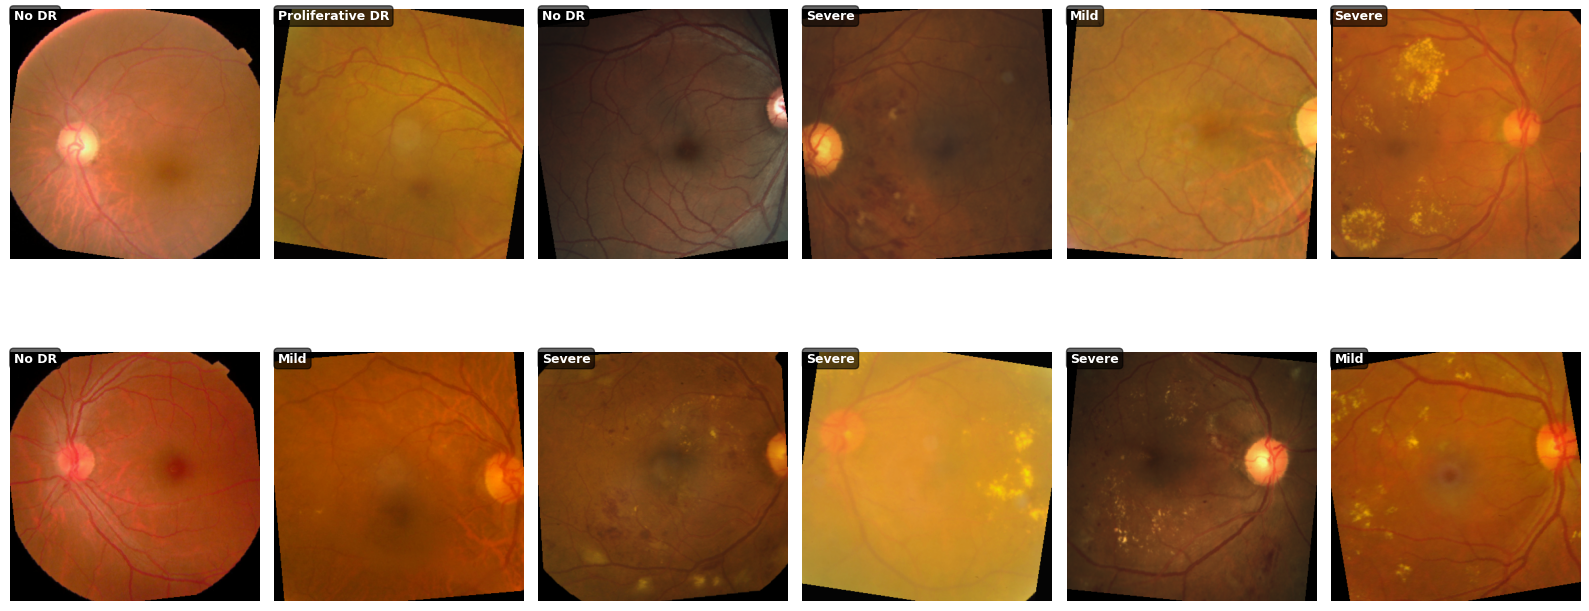

In [33]:
#Referenced from https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

def show_batch(images, labels, n=24, ncols=6):
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(16, 8))

    class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

    for i in range(n):
        ax = plt.subplot(nrows, ncols, i + 1)
        img = denorm(images[i].cpu()).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        ax.axis('off')

        label_text = class_names[int(labels[i])]
        ax.text(
            5, 15, label_text,
            color='white', fontsize=9, weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6)
        )

    plt.tight_layout()
    plt.show()


# === Example usage ===
inputs, labels = next(iter(train_loader))
show_batch(inputs, labels, n=12, ncols=6)


In [48]:
MODEL_DIR = "/content/drive/MyDrive/RetinXplain/models"
os.makedirs(MODEL_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnet_b4_best.pt")

num_classes = 5
TOTAL_EPOCHS = 30
HEAD_LR = 3e-4          # classifier LR
BACKBONE_LR = 1e-4    # backbone LR
WEIGHT_DECAY = 1e-4

UNFREEZE_EPOCH = 3

# --- EfficientNet-B4 as backbone ---
weights = EfficientNet_B4_Weights.IMAGENET1K_V1
model = efficientnet_b4(weights=weights)

# # 1) Freeze only EARLY feature blocks – let deeper ones adapt
# for p in model.features[:5].parameters():   # early layers
#     p.requires_grad = False

# for p in model.features[5:].parameters():   # deeper layers
#     p.requires_grad = True


for p in model.features.parameters():       #Freeze all backbone first, only train the head
    p.requires_grad = False


# 2) Replace classifier for 5-class DR
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, num_classes)

# 3) Make classifier trainable
for p in model.classifier.parameters():
    p.requires_grad = True

model = model.to(device)


# --- Optimizer: classifier + deeper feature blocks ---
# optimizer = torch.optim.AdamW(
#     [
#         {"params": model.classifier.parameters(),  "lr": HEAD_LR},
#         {"params": model.features[5:].parameters(), "lr": BACKBONE_LR},
#     ],
#     weight_decay=WEIGHT_DECAY,
# )

optimizer = torch.optim.AdamW(
    [{"params": model.classifier.parameters(), "lr": HEAD_LR}],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=TOTAL_EPOCHS,
    eta_min=1e-6,
)


wandb_run = wandb.init(
    project="retinexplain-dr",
    name="efficientnet-b4-aptos-ce",
    config={
        "model": "efficientnet_b4",
        "img_size": CROP_SIZE,
        "batch_size": batch_size,
        "total_epochs": TOTAL_EPOCHS,
        "unfreeze_epoch": UNFREEZE_EPOCH,
        "head_lr": HEAD_LR,
        "backbone_lr": BACKBONE_LR,
        "weight_decay": WEIGHT_DECAY,
        "loss": "CrossEntropyLoss",
        "sampling": "WeightedRandomSampler",
        "augmentations": [
            "SmartFundusCrop",
            "Resize(380)",
            "RandomResizedCrop(380, scale=(0.9, 1.0), ratio=(0.95, 1.05))",
            "RandomHorizontalFlip(p=0.5)",
            "RandomRotation(±15°)",
            "ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10, hue=0.03)",
            "ToTensor",
            "Normalize(ImageNet mean/std)"
        ]
    }
)

# Watch with W&B (optional)
wandb.watch(model, log="all", log_freq=100)


In [35]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.
    alpha: tensor of shape [num_classes] (class weights)
    gamma: focusing parameter; typical values: 1–3.
    """
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: [B, C], targets: [B]
        ce_loss = F.cross_entropy(inputs, targets, reduction="none", weight=self.alpha)
        pt = torch.exp(-ce_loss)  # pt = probability of true class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss


#criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0, reduction="mean")
#criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.05   # or 0.1 to be more aggressive
)



In [36]:
from tqdm.auto import tqdm

def get_current_lrs(optimizer):
    return [group['lr'] for group in optimizer.param_groups]

def unfreeze_last_block(model):
    """Unfreeze the last EfficientNet-B4 blocks for fine-tuning."""
    for p in model.features[-3:].parameters():
        p.requires_grad = True

def train_model(model, criterion, optimizer, scheduler=None, num_epochs=30):
    since = time.time()
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [],   "val_acc": [],
        "lr_head": [], "lr_backbone": []
    }


    best_acc = 0.0
    best_model_path = BEST_MODEL_PATH
    torch.save(model.state_dict(), best_model_path)

    for epoch in range(num_epochs):
        epoch_lrs = get_current_lrs(optimizer)
        lr_msg = " | ".join([f"group {i}: {lr:.6f}" for i, lr in enumerate(epoch_lrs)])
        print(f"Epoch {epoch + 1}/{num_epochs}  |  LRs -> {lr_msg}")
        print("-" * 50)

        epoch_logs = {"epoch": epoch + 1}

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()
            running_loss = 0.0
            running_corrects = 0

            loop = tqdm(dataloaders[phase], desc=f"{phase:>5}", leave=False)
            for inputs, labels in loop:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            print(f"{phase:>5} | loss: {epoch_loss:.4f}  acc: {epoch_acc*100:5.2f}%")

            if phase == "train":
                history["train_loss"].append(epoch_loss)
                history["train_acc"].append(epoch_acc)
                epoch_logs["train_loss"] = epoch_loss
                epoch_logs["train_acc"] = epoch_acc
            else:
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(epoch_acc)
                epoch_logs["val_loss"] = epoch_loss
                epoch_logs["val_acc"] = epoch_acc

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_path)

        # 🔓 Unfreeze last block at UNFREEZE_EPOCH
        if (epoch + 1) == UNFREEZE_EPOCH and len(optimizer.param_groups) == 1:
            print(">> Unfreezing last EfficientNet blocks and adding to optimizer")
            unfreeze_last_block(model)
            optimizer.add_param_group({
                "params": model.features[-3:].parameters(),
                "lr": BACKBONE_LR,
            })


        # Step LR scheduler (will now affect both groups)
        if scheduler is not None:
            scheduler.step()

        # Record LRs (after possible unfreeze)
        epoch_lrs = get_current_lrs(optimizer)
        history["lr_head"].append(epoch_lrs[0])
        history["lr_backbone"].append(epoch_lrs[1] if len(epoch_lrs) > 1 else None)

        epoch_logs["lr_head"] = epoch_lrs[0]
        if len(epoch_lrs) > 1:
            epoch_logs["lr_backbone"] = epoch_lrs[1]
        epoch_logs["best_val_acc"] = best_acc

        wandb.log(epoch_logs)

        dt = time.time() - since
        print(f"Training time so far: {dt//60:.0f}m {dt%60:.0f}s")
        print(f"Best val Acc so far: {best_acc*100:.2f}%")

        # Keep best weights in memory
        model.load_state_dict(torch.load(best_model_path, map_location=device))

    return model, history


In [37]:

def evaluate(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

def predict_all(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(1)
            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    return np.array(y_true), np.array(y_pred)


# Train
model, history = train_model(
    model,
    criterion,
    optimizer,
    scheduler,
    num_epochs=TOTAL_EPOCHS,
)

# Test
test_acc = evaluate(test_loader)
print(f"Test accuracy: {test_acc*100:.2f}%")

y_true, y_pred = predict_all(model, test_loader, device)
macro_f1 = f1_score(y_true, y_pred, average='macro') # Assign to macro_f1
print("Macro-F1:", f1_score(y_true, y_pred, average='macro'))
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=3))

# --- W&B logging for test results + confusion matrix ---
wandb.log({
    "test_accuracy": test_acc,
    "test_macro_f1": macro_f1,
})

# Confusion matrix plot
cm_plot = wandb.plot.confusion_matrix(
    probs=None,
    y_true=y_true,
    preds=y_pred,
    class_names=[class_names[i] for i in sorted(class_names.keys())]
)
wandb.log({"confusion_matrix": cm_plot})

# --- Log best model as a W&B Artifact (WMDB / Model Registry) ---
artifact = wandb.Artifact(
    name="efficientnet-b4-dr",
    type="model",
    metadata={
        "architecture": "efficientnet_b4",
        "num_classes": num_classes,
        "img_size": CROP_SIZE,
    },
)
artifact.add_file(BEST_MODEL_PATH)
wandb.log_artifact(artifact)


Epoch 1/30  |  LRs -> group 0: 0.000300
--------------------------------------------------


train:   0%|          | 0/92 [00:00<?, ?it/s]

train | loss: 1.4687  acc: 24.16%


  val:   0%|          | 0/12 [00:00<?, ?it/s]

  val | loss: 1.6371  acc:  8.47%
Training time so far: 15m 14s
Best val Acc so far: 8.47%
Epoch 2/30  |  LRs -> group 0: 0.000299
--------------------------------------------------


...

train:   0%|          | 0/92 [00:00<?, ?it/s]

train | loss: 0.8523  acc: 62.53%


  val:   0%|          | 0/12 [00:00<?, ?it/s]

  val | loss: 1.2639  acc: 62.84%
Training time so far: 461m 14s
Best val Acc so far: 64.48%
Test accuracy: 66.94%
Macro-F1: 0.46660904606834086
[[187  11   0   0   1]
 [  1  22   0   3   4]
 [  1  20   6  38  22]
 [  0   0   0  13   4]
 [  1   4   0  11  17]]
              precision    recall  f1-score   support

           0      0.984     0.940     0.961       199
           1      0.386     0.733     0.506        30
           2      1.000     0.069     0.129        87
           3      0.200     0.765     0.317        17
           4      0.354     0.515     0.420        33

    accuracy                          0.669       366
   macro avg      0.585     0.604     0.467       366
weighted avg      0.846     0.669     0.647       366



<Artifact efficientnet-b4-dr>

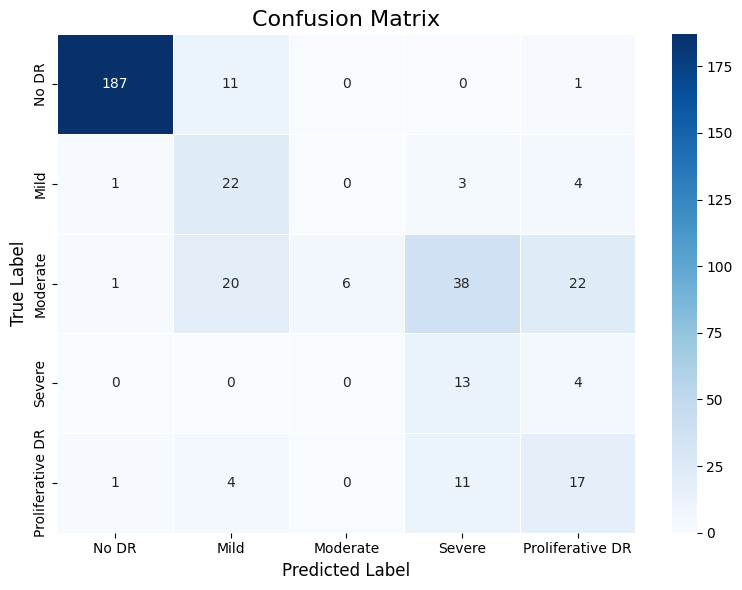

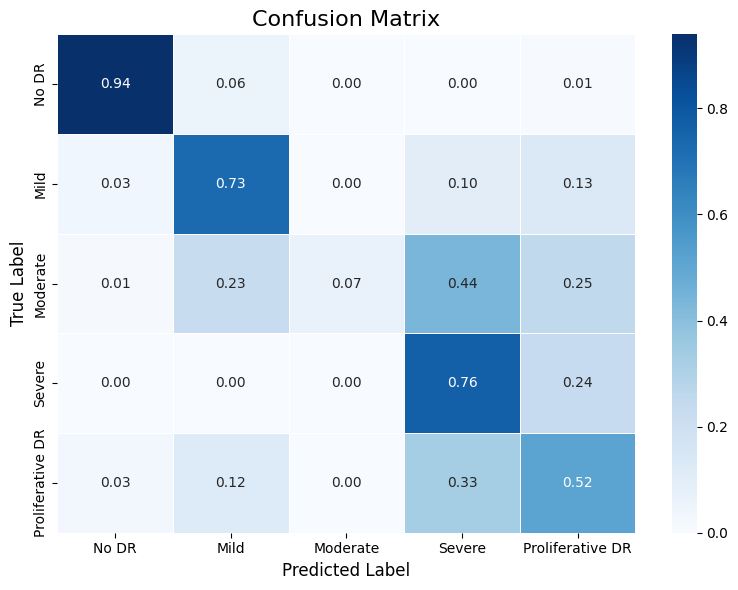

In [49]:
def plot_confusion_matrix_seaborn(y_true, y_pred, class_names, normalize=False):
    """
    y_true, y_pred: numpy arrays (integers 0–4)
    class_names: list of names in index order [0..4]
    normalize: bool — whether to show row-normalized matrix
    """
    # Compute CM
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    # Normalize per row (true label)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        linewidths=0.5,
        linecolor='white'
    )

    plt.ylabel("True Label", fontsize=12)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.title("Confusion Matrix", fontsize=16)
    plt.tight_layout()
    plt.show()

names_list = [class_names[k] for k in sorted(class_names.keys())]

# -- raw counts --
plot_confusion_matrix_seaborn(y_true, y_pred, names_list, normalize=False)

# -- normalized --
plot_confusion_matrix_seaborn(y_true, y_pred, names_list, normalize=True)

# GradCam Implementations

In [69]:
import random
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ---- CONFIG ----
# Try -3, -4, or -2 and compare the maps
GRADCAM_LAYER_INDEX = -2   # Changed to -2 for potentially sharper explanations

# --------------------------
# Load best weights & eval mode
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device).eval()

# Make sure chosen block has grads for CAM
for p in model.features[GRADCAM_LAYER_INDEX].parameters():
    p.requires_grad = True

target_layers = [model.features[GRADCAM_LAYER_INDEX]]

cam = GradCAM(
    model=model,
    target_layers=target_layers,
)
cropper = SmartFundusCrop()

def get_gradcam_for_index(ds_idx, mode="pred"):
    """
    mode:
      - 'pred': CAM for the model's predicted class (what you had before)
      - 'true': CAM for the ground-truth class (more clinically intuitive)
      - int k : CAM for class index k (e.g. 3 = Severe, 4 = Proliferative)
    """
    # --- raw image path from validation set ---
    img_id = val_df.iloc[ds_idx]["id_code"]
    raw_path = os.path.join(valid_images, f"{img_id}.png")
    if not os.path.exists(raw_path):
        raw_path = os.path.join(valid_images, f"{img_id}.jpg")

    raw_pil = Image.open(raw_path).convert("RGB")

    # crop out black border so we only work on fundus
    fundus_pil = cropper(raw_pil)
    fundus_np  = np.array(fundus_pil).astype(np.float32) / 255.0

    true_label = int(val_df.iloc[ds_idx]["diagnosis"])

    # model input (same as validation transform)
    model_input = data_transforms['validation'](fundus_pil).unsqueeze(0).to(device)
    logits = model(model_input)
    pred_label = logits.argmax(1).item()

    # ---- choose which class to explain ----
    if mode == "pred":
        target_class = pred_label
    elif mode == "true":
        target_class = true_label
    elif isinstance(mode, int):
        target_class = mode
    else:
        raise ValueError(f"Unknown mode '{mode}'")

    cam_target = [ClassifierOutputTarget(target_class)]

    # Grad-CAM (eigen_smooth=True gives nicer, less noisy maps)
    grayscale_cam = cam(
        input_tensor=model_input,
        targets=cam_target,
        eigen_smooth=True
    )[0]   # [H', W']

    # resize CAM to fundus size
    h, w, _ = fundus_np.shape
    resized_cam = cv2.resize(grayscale_cam, (w, h))

    gradcam_overlay = show_cam_on_image(
        fundus_np.astype(np.float32), resized_cam, use_rgb=True, image_weight=0.6
    )

    return fundus_np, gradcam_overlay, true_label, pred_label, target_class

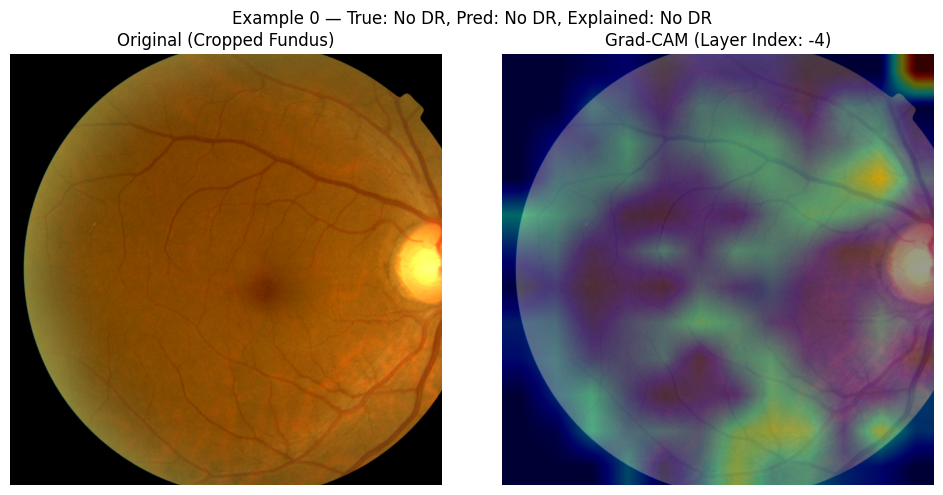

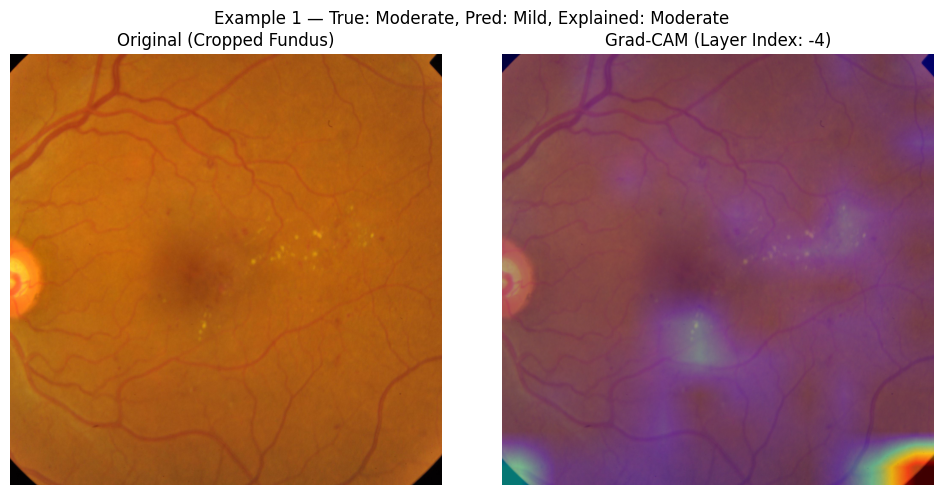

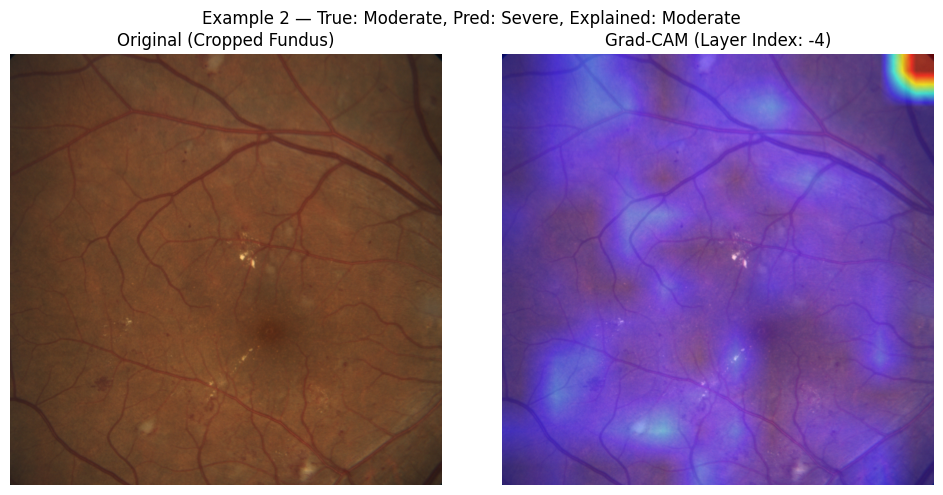

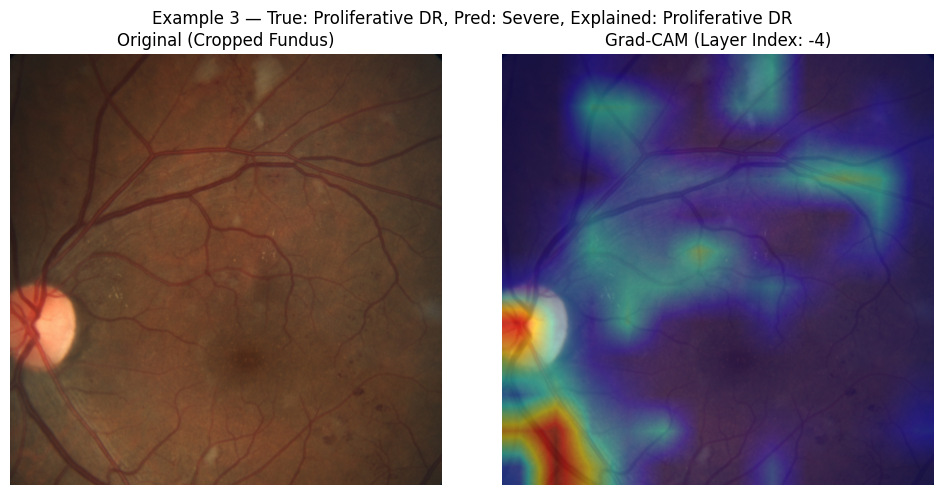

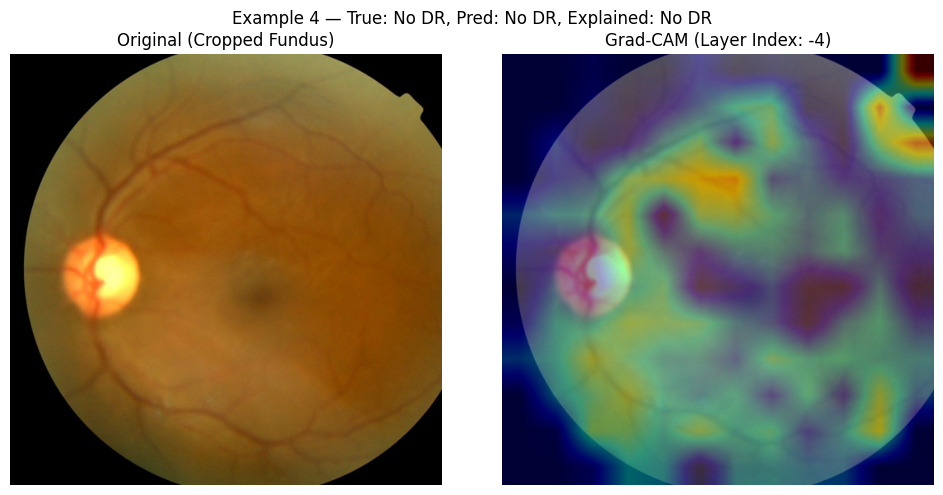

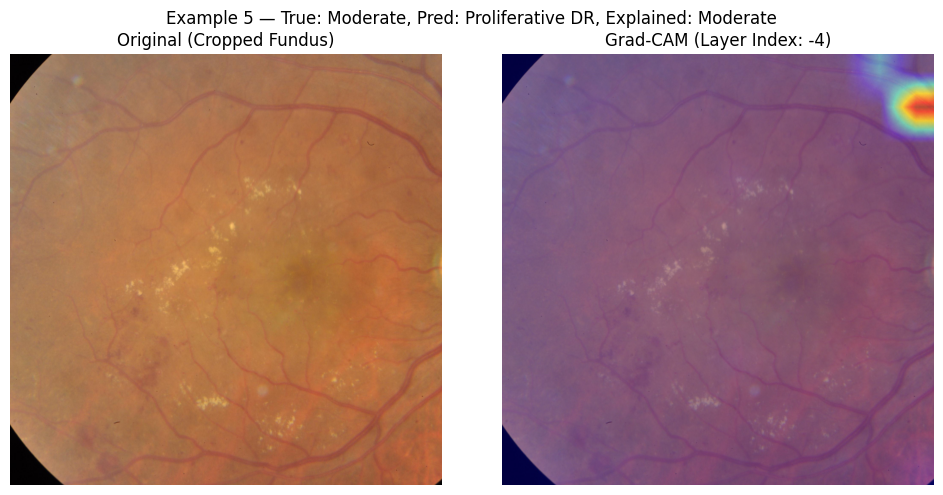

In [70]:
N_EXAMPLES = 6
indices = random.sample(range(len(val_df)), N_EXAMPLES)

for i, ds_idx in enumerate(indices):
    # Change mode here: "pred", "true", or e.g. 3 for "Severe"
    fundus_np, gradcam_overlay, true_label, pred_label, explained_class = \
        get_gradcam_for_index(ds_idx, mode="true")

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(
        f"Example {i} — True: {class_names[true_label]}, "
        f"Pred: {class_names[pred_label]}, "
        f"Explained: {class_names[explained_class]}"
    )

    axs[0].imshow(fundus_np)
    axs[0].set_title("Original (Cropped Fundus)")
    axs[0].axis("off")

    axs[1].imshow(gradcam_overlay)
    axs[1].set_title("Grad-CAM (Layer Index: -4)")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

# Lime Implementations

In [53]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

# LIME explainer
explainer = lime_image.LimeImageExplainer()

def lime_predict(images_np):
    """
    images_np: list/array of images (H,W,3) in [0,1] or [0,255].
    Returns softmax probabilities for each image.
    """
    model.eval()
    batch_tensors = []

    for img in images_np:
        img = img.astype(np.float32)
        if img.max() > 1.0:
            img = img / 255.0

        pil_img = Image.fromarray((img * 255).astype(np.uint8))
        t = data_transforms['validation'](pil_img)  # same preprocessing as validation
        batch_tensors.append(t)

    batch = torch.stack(batch_tensors).to(device)

    with torch.no_grad():
        logits = model(batch)
        probs = F.softmax(logits, dim=1).cpu().numpy()

    return probs

def get_lime_for_fundus(fundus_np, pred_label, num_features=8, num_samples=50):
    """
    fundus_np: cropped fundus image in [0,1], shape (H,W,3)
    pred_label: class index we want LIME to explain
    Returns: lime_overlay (H,W,3) with boundaries drawn.
    """
    explanation = explainer.explain_instance(
        fundus_np,
        lime_predict,
        top_labels=5,
        num_samples=num_samples,
        hide_color=0,
    )

    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=True,
        num_features=num_features,
        hide_rest=False,
    )

    if temp.max() > 1:
        lime_vis = temp.astype(np.float32) / 255.0
    else:
        lime_vis = temp

    lime_overlay = mark_boundaries(lime_vis, mask)
    return lime_overlay


In [64]:
N_EXAMPLES = 1  # how many images to visualize

# Re-initialize wandb run if it's not active
if wandb.run is None:
    wandb_run = wandb.init(
        project="retinexplain-dr",
        name="efficientnet-b4-aptos-ce", # You can give it a new name for this session
        reinit=True # Important for restarting a run within a script
    )

# sample random indices from the validation set
indices = random.sample(range(len(val_df)), N_EXAMPLES)

for i, ds_idx in enumerate(indices):
    # Grad-CAM part (now explaining the predicted class)
    fundus_np, gradcam_overlay, true_label, pred_label, explained_class = get_gradcam_for_index(ds_idx, mode="pred")

    # LIME part (same cropped fundus + predicted class)
    lime_overlay = get_lime_for_fundus(fundus_np, pred_label)

    # Plot side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(14, 6))
    fig.suptitle(
        f"Example {i} — True: {class_names[true_label]}, Pred: {class_names[pred_label]}"
    )

    axs[0].imshow(fundus_np)
    axs[0].set_title("Original (Cropped Fundus)")
    axs[0].axis("off")

    axs[1].imshow(gradcam_overlay)
    axs[1].set_title("Grad-CAM (Layer Index: -2)")
    axs[1].axis("off")

    axs[2].imshow(lime_overlay)
    axs[2].set_title("LIME")
    axs[2].axis("off")

    plt.tight_layout()
     # Log the figure to W&B so it’s attached to this run
    wandb.log({f"explainability_example_{i}": wandb.Image(fig)})

    plt.show()
wandb.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


KeyboardInterrupt: 